# Step 02 — region-aware ATF thresholds and feature reliability

This notebook rebuilds the experimental feature table and threshold model from the 37 ATF files.

Scientific purpose:

- keep `DH` and `VH` as first-class factors;
- replace the legacy threshold CSV with `region × condition × sweep × feature` summaries;
- quantify redundancy and missingness before later fitting steps;
- benchmark whether optional numba acceleration is actually needed for this step.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

from src.step02_thresholds import load_step02_outputs, run_step02_rebuild_atf_thresholds

PROJECT_ROOT = Path('.').resolve()
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'features'
FORCE_RECOMPUTE = False
PROJECT_ROOT, OUTPUT_DIR

(PosixPath('/mnt/data/astromodel_step02_work'),
 PosixPath('/mnt/data/astromodel_step02_work/outputs/features'))

## Run the full step-02 pipeline

This writes the machine-readable outputs under `outputs/features/` and returns the in-memory tables for inspection.


In [2]:
if FORCE_RECOMPUTE or not (OUTPUT_DIR / 'performance_benchmark.csv').exists():
    results = run_step02_rebuild_atf_thresholds(PROJECT_ROOT, output_dir=OUTPUT_DIR, build_benchmark=True)
else:
    results = load_step02_outputs(OUTPUT_DIR)
summary = results['analysis_summary']
summary

{'n_files': 37,
 'n_rows': 222,
 'n_sweeps_per_file_min': 6,
 'n_sweeps_per_file_max': 6,
 'n_plateau_reached': 117,
 'n_has_undershoot': 156,
 'mean_artifact_fraction': 0.0010680356481726344,
 'n_region_specific_threshold_rows': 432,
 'n_region_pooled_threshold_rows': 216,
 'n_global_pooled_threshold_rows': 72,
 'redundant_pairs': 1,
 'mean_reliability_weight': 0.8939177939177939}

## Region-condition cell counts

In [3]:
counts = results['region_condition_cell_counts']
counts

,region,condition,n_cells,expected_n_cells,matches_expected,small_stratum
0,DH,CONTROL,7,7,True,False
1,DH,MFA,6,6,True,False
2,DH,MFA_BA,6,6,True,False
3,VH,CONTROL,4,4,True,True
4,VH,MFA,7,7,True,False
5,VH,MFA_BA,7,7,True,False


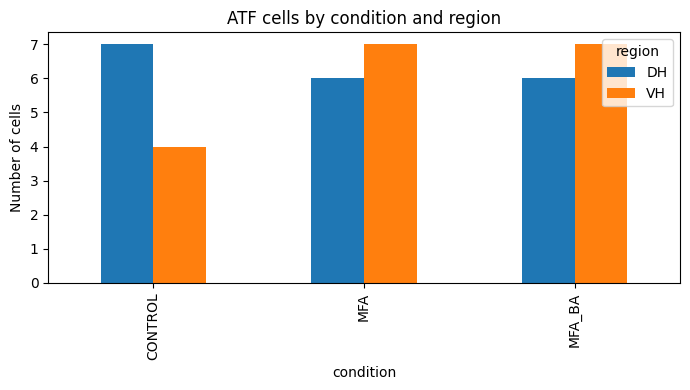

In [4]:
pivot_counts = counts.pivot(index='condition', columns='region', values='n_cells').loc[['CONTROL','MFA','MFA_BA']]
ax = pivot_counts.plot(kind='bar', figsize=(7,4))
ax.set_ylabel('Number of cells')
ax.set_title('ATF cells by condition and region')
plt.tight_layout()
plt.show()

## Legacy threshold structure versus the new threshold structure

The legacy threshold file is kept for comparison only. It lacks pharmacological condition and therefore cannot be the primary reviewer-facing threshold model.


In [5]:
legacy = results['legacy_threshold_preview']
print('Legacy groups:', sorted(legacy['group'].unique().tolist()))
print('Legacy shape:', legacy.shape)
legacy.head()

Legacy groups: ['T', 'VH', 'pooled']
Legacy shape: (144, 18)


,group,sweep,feature,n,mean,median,std,min,q1,q3,max,iqr,ci95_low,ci95_high,acceptable_low_q1,acceptable_high_q3,acceptable_low_ci95,acceptable_high_ci95
0,pooled,1,peak_depolarization_mV,9,7.1331,7.3083,0.9420,5.5818,6.3880,7.6025,8.6889,1.2146,6.4091,7.8572,6.3880,7.6025,6.4091,7.8572
1,T,1,peak_depolarization_mV,5,7.5547,7.6025,0.8346,6.3880,7.2864,7.8076,8.6889,0.5212,6.5185,8.5909,7.2864,7.8076,6.5185,8.5909
2,VH,1,peak_depolarization_mV,4,6.6062,6.7380,0.8781,5.5818,6.0212,7.3229,7.3670,1.3017,5.2089,8.0035,6.0212,7.3229,5.2089,8.0035
3,pooled,1,rise_slope_mV_per_s,9,6.9449,6.5183,2.5914,3.8319,4.4107,9.2764,10.5347,4.8657,4.9530,8.9368,4.4107,9.2764,4.9530,8.9368
4,T,1,rise_slope_mV_per_s,5,8.9232,9.2764,1.4712,6.5183,8.9771,9.3095,10.5347,0.3324,7.0965,10.7499,8.9771,9.3095,7.0965,10.7499


In [6]:
thresholds = results['condition_region_sweep_thresholds']
thresholds[['threshold_scope','condition','region','sweep','feature']].drop_duplicates().head(12)

,threshold_scope,condition,region,sweep,feature
0,region_specific,CONTROL,DH,1,decay_slope_mV_per_s
1,region_specific,CONTROL,DH,1,decay_tau_s
2,region_specific,CONTROL,DH,1,has_undershoot
3,region_specific,CONTROL,DH,1,peak_depolarization_mV
4,region_specific,CONTROL,DH,1,plateau_level_mV
5,region_specific,CONTROL,DH,1,plateau_reached
6,region_specific,CONTROL,DH,1,plateau_slope_mV_per_s
7,region_specific,CONTROL,DH,1,return_slope_mV_per_s
8,region_specific,CONTROL,DH,1,rise_slope_mV_per_s
9,region_specific,CONTROL,DH,1,rise_tau_s


## Canonical sweep-level feature table

In [7]:
feature_df = results['feature_table_by_sweep']
feature_df[['file_id','region','condition','sweep','peak_depolarization_mV','stim_end_depolarization_mV','plateau_reached','has_undershoot','return_slope_mV_per_s']].head(12)

,file_id,region,condition,sweep,peak_depolarization_mV,stim_end_depolarization_mV,plateau_reached,has_undershoot,return_slope_mV_per_s
0,1_DH_1,DH,CONTROL,1,7.286412,6.7444,True,True,0.032342
1,1_DH_1,DH,CONTROL,2,10.645808,9.9183,True,True,0.041053
2,1_DH_1,DH,CONTROL,3,14.039336,13.2752,True,True,0.047600
3,1_DH_1,DH,CONTROL,4,16.992200,16.1438,True,True,0.047482
4,1_DH_1,DH,CONTROL,5,19.937736,19.6228,True,True,0.066319
5,1_DH_1,DH,CONTROL,6,22.542744,22.1558,True,True,0.050254
6,1_DH_2,DH,CONTROL,1,7.602528,6.6223,True,True,0.029836
7,1_DH_2,DH,CONTROL,2,11.071756,10.1623,True,True,0.046686
8,1_DH_2,DH,CONTROL,3,14.328640,13.6414,True,True,0.040838
9,1_DH_2,DH,CONTROL,4,17.229036,16.3575,True,True,0.073199


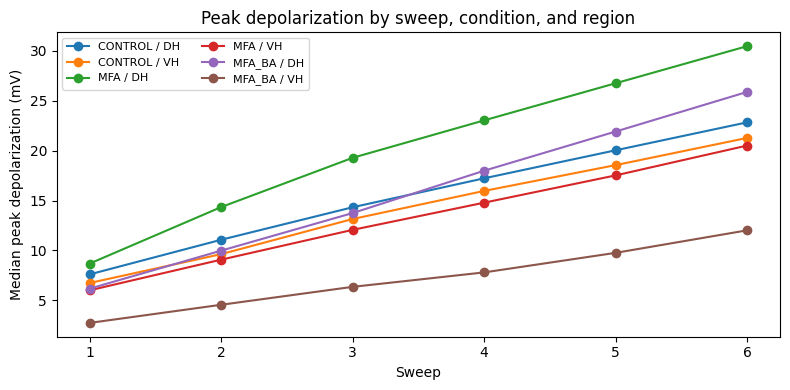

In [8]:
median_peak = (
    feature_df.groupby(['condition','region','sweep'])['peak_depolarization_mV']
    .median()
    .reset_index()
)
fig, ax = plt.subplots(figsize=(8,4))
for (condition, region), group in median_peak.groupby(['condition','region']):
    ax.plot(group['sweep'], group['peak_depolarization_mV'], marker='o', label=f'{condition} / {region}')
ax.set_xlabel('Sweep')
ax.set_ylabel('Median peak depolarization (mV)')
ax.set_title('Peak depolarization by sweep, condition, and region')
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## Redundancy diagnostics

In [9]:
corr_summary = results['feature_correlation_summary']
corr_summary.head(10)

,feature_a,feature_b,spearman_r,n_rows,is_redundant
0,peak_depolarization_mV,stim_end_depolarization_mV,0.998382,222,True
1,rise_slope_mV_per_s,decay_slope_mV_per_s,0.889111,222,False
2,decay_slope_mV_per_s,undershoot_magnitude_mV,0.778737,222,False
3,rise_slope_mV_per_s,undershoot_magnitude_mV,0.775867,222,False
4,peak_depolarization_mV,rise_slope_mV_per_s,0.682883,222,False
5,rise_tau_s,plateau_slope_mV_per_s,0.674975,222,False
6,stim_end_depolarization_mV,plateau_level_mV,0.665265,117,False
7,stim_end_depolarization_mV,rise_slope_mV_per_s,0.661448,222,False
8,peak_depolarization_mV,plateau_level_mV,0.657795,117,False
9,rise_tau_s,decay_tau_s,0.650338,222,False


Spearman(peak, stim_end) = 0.9983822062429291


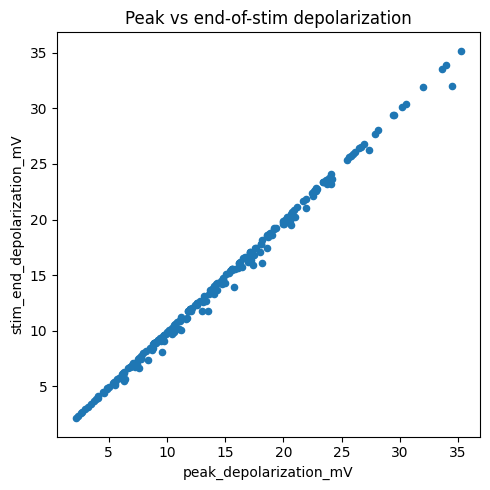

In [10]:
spearman_peak_stim = feature_df[['peak_depolarization_mV','stim_end_depolarization_mV']].corr(method='spearman').iloc[0,1]
print('Spearman(peak, stim_end) =', spearman_peak_stim)
ax = feature_df.plot.scatter(x='peak_depolarization_mV', y='stim_end_depolarization_mV', figsize=(5,5))
ax.set_title('Peak vs end-of-stim depolarization')
plt.tight_layout()
plt.show()

## Reliability weights

In [11]:
reliability = results['feature_reliability_weights']
reliability_summary = (
    reliability[reliability['threshold_scope'] == 'region_specific']
    .groupby('feature', as_index=False)[['coverage_weight','redundancy_penalty','reliability_weight']]
    .mean()
    .sort_values('reliability_weight')
)
reliability_summary

,feature,coverage_weight,redundancy_penalty,reliability_weight
10,stim_end_depolarization_mV,1.000000,0.5,0.500000
4,plateau_level_mV,0.546296,1.0,0.546296
7,return_slope_mV_per_s,0.683862,1.0,0.683862
0,decay_slope_mV_per_s,1.000000,1.0,1.000000
3,peak_depolarization_mV,1.000000,1.0,1.000000
2,has_undershoot,1.000000,1.0,1.000000
5,plateau_reached,1.000000,1.0,1.000000
1,decay_tau_s,1.000000,1.0,1.000000
6,plateau_slope_mV_per_s,1.000000,1.0,1.000000
8,rise_slope_mV_per_s,1.000000,1.0,1.000000


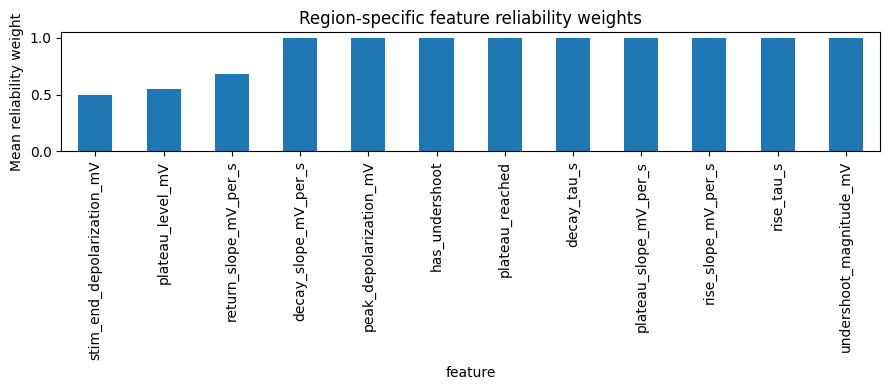

In [12]:
ax = reliability_summary.set_index('feature')['reliability_weight'].plot(kind='bar', figsize=(9,4))
ax.set_ylabel('Mean reliability weight')
ax.set_title('Region-specific feature reliability weights')
plt.tight_layout()
plt.show()

## Region-effect summaries

In [13]:
region_effects = results['region_effect_summary']
region_effects.head(12)

,condition,sweep,feature,family,n_cells_DH,n_cells_VH,small_stratum,dh_median,vh_median,dh_mean,vh_mean,dh_minus_vh_median,dh_minus_vh_ci95_low,dh_minus_vh_ci95_high
0,CONTROL,1,decay_slope_mV_per_s,primary_continuous,7,4,True,10.662435,5.873104,9.119879,5.674447,4.789331,-1.939365,6.572201
1,CONTROL,2,decay_slope_mV_per_s,primary_continuous,7,4,True,14.567700,8.347715,12.750709,8.474969,6.219984,-3.481587,10.263448
2,CONTROL,3,decay_slope_mV_per_s,primary_continuous,7,4,True,18.437218,11.563394,16.243737,11.782491,6.873823,-6.164339,12.394463
3,CONTROL,4,decay_slope_mV_per_s,primary_continuous,7,4,True,22.528802,12.309478,18.668427,12.637449,10.219324,-4.622096,12.943256
4,CONTROL,5,decay_slope_mV_per_s,primary_continuous,7,4,True,24.857651,15.360341,21.097816,15.516927,9.497310,-8.592431,14.745022
5,CONTROL,6,decay_slope_mV_per_s,primary_continuous,7,4,True,27.345149,14.962493,21.542552,15.467092,12.382656,-8.287216,16.461163
6,MFA,1,decay_slope_mV_per_s,primary_continuous,6,7,False,4.782121,3.071973,4.348748,3.396745,1.710148,-1.419207,3.068364
7,MFA,2,decay_slope_mV_per_s,primary_continuous,6,7,False,7.358873,4.780713,6.623817,5.322119,2.578160,-2.266898,4.945056
8,MFA,3,decay_slope_mV_per_s,primary_continuous,6,7,False,9.236832,6.046020,8.406027,7.017825,3.190811,-3.609424,7.368115
9,MFA,4,decay_slope_mV_per_s,primary_continuous,6,7,False,10.098323,6.827218,8.997645,8.323770,3.271104,-5.143774,6.222104


In [14]:
control_small = region_effects[(region_effects['condition'] == 'CONTROL') & (region_effects['small_stratum'])]
control_small[['condition','sweep','feature','n_cells_DH','n_cells_VH','small_stratum']].head(12)

,condition,sweep,feature,n_cells_DH,n_cells_VH,small_stratum
0,CONTROL,1,decay_slope_mV_per_s,7,4,True
1,CONTROL,2,decay_slope_mV_per_s,7,4,True
2,CONTROL,3,decay_slope_mV_per_s,7,4,True
3,CONTROL,4,decay_slope_mV_per_s,7,4,True
4,CONTROL,5,decay_slope_mV_per_s,7,4,True
5,CONTROL,6,decay_slope_mV_per_s,7,4,True
18,CONTROL,1,decay_tau_s,7,4,True
19,CONTROL,2,decay_tau_s,7,4,True
20,CONTROL,3,decay_tau_s,7,4,True
21,CONTROL,4,decay_tau_s,7,4,True


## Performance and optional numba decision

In [15]:
benchmark = results['performance_benchmark']
benchmark

,stage,engine,elapsed_seconds,n_rows,note,compute_speedup_numba_vs_numpy,estimated_total_gain_seconds,numba_decision
0,preprocess,shared,24.901983,60,parse_atf + robust artifact preprocessing for ...,NaN,NaN,NaN
1,feature_extraction,numpy,1.378158,60,extract_features over cached preprocessed traces,NaN,NaN,NaN
2,feature_extraction,numba,1.849748,60,extract_features over cached preprocessed trac...,NaN,NaN,NaN
3,decision,keep_numpy,30.001167,60,step02 is dominated by ATF parsing and artifac...,0.745052,-1.744884,keep_numpy_default


In [16]:
decision_row = benchmark[benchmark['stage'] == 'decision'].iloc[0]
print('Decision:', decision_row['numba_decision'])
print('Rationale:', decision_row['note'])

Decision: keep_numpy_default
Rationale: step02 is dominated by ATF parsing and artifact preprocessing; numba does not change the primary bottleneck


## Output files written by this notebook

In [17]:
sorted(str(p.relative_to(PROJECT_ROOT)) for p in OUTPUT_DIR.glob('*'))

['outputs/features/analysis_summary.json',
 'outputs/features/atf_region_condition_inventory.csv',
 'outputs/features/condition_region_sweep_thresholds.csv',
 'outputs/features/feature_correlation_summary.csv',
 'outputs/features/feature_reliability_weights.csv',
 'outputs/features/feature_table_by_sweep.csv',
 'outputs/features/legacy_threshold_preview.csv',
 'outputs/features/performance_benchmark.csv',
 'outputs/features/preprocess_qc_by_sweep.csv',
 'outputs/features/region_condition_cell_counts.csv',
 'outputs/features/region_effect_summary.csv']